In [ ]:
# 1. Uninstall broken versions
!pip uninstall -y mamba-ssm causal-conv1d

# 2. Install causal-conv1d first, forcing it to compile locally
!CAUSAL_CONV1D_FORCE_BUILD=TRUE pip install causal-conv1d --no-build-isolation

# 3. Install Mamba-SSM afterwards
!MAMBA_FORCE_BUILD=TRUE pip install mamba-ssm --no-build-isolation

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 4
EPOCHS = 30 
LEARNING_RATE = 1e-4
IMG_SIZE = 224
NUM_CLASSES = 9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Loading & ImageNet Normalization
# Pre-trained models require exact ImageNet normalization metrics
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Added for skin tone variance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

kaggle_root = '/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
train_dir = os.path.join(kaggle_root, 'Train')
test_dir = os.path.join(kaggle_root, 'Test')

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 3. Lightweight CNN Ensemble Architecture
class LightweightCNNEnsemble(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(LightweightCNNEnsemble, self).__init__()
        
        # Load pre-trained base models
        self.efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        
        # Strip the final classification heads, leaving only the feature extractors
        self.efficientnet.classifier = nn.Identity()
        self.mobilenet.classifier = nn.Identity()
        
        # EfficientNet-B0 outputs 1280 features; MobileNetV3-Small outputs 576
        combined_features = 1280 + 576
        
        # Custom classification head for the 9-class ISIC dataset
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(combined_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from both networks
        x1 = self.efficientnet(x)
        x2 = self.mobilenet(x)
        
        # Concatenate features along the channel dimension
        fused_features = torch.cat((x1, x2), dim=1)
        
        # Classify based on the fused feature map
        return self.classifier(fused_features)

model = LightweightCNNEnsemble().to(device)
criterion = nn.CrossEntropyLoss()

# Using Adam with weight decay for regularization
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# 4. Training Loop
print("Starting Ensemble Training...")
best_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(train_loader):.4f} | Accuracy: {train_acc:.2f}%")
    
    # Step the learning rate scheduler
    scheduler.step(train_acc)
    
    # Save the best model weights dynamically
    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(model.state_dict(), "best_cnn_ensemble_isic.pth")

print("Training Complete. Optimal weights saved in preparation for the April 2026 manuscript submission.")



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 183MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 122MB/s]


Starting Ensemble Training...
Epoch [1/30] Loss: 1.7780 | Accuracy: 39.62%
Epoch [2/30] Loss: 1.1368 | Accuracy: 62.93%
Epoch [3/30] Loss: 0.8504 | Accuracy: 71.33%
Epoch [4/30] Loss: 0.6924 | Accuracy: 75.48%
Epoch [5/30] Loss: 0.5842 | Accuracy: 78.34%
Epoch [6/30] Loss: 0.5098 | Accuracy: 81.64%
Epoch [7/30] Loss: 0.4326 | Accuracy: 82.80%
Epoch [8/30] Loss: 0.3826 | Accuracy: 85.08%
Epoch [9/30] Loss: 0.3375 | Accuracy: 86.42%
Epoch [10/30] Loss: 0.3131 | Accuracy: 87.14%
Epoch [11/30] Loss: 0.2917 | Accuracy: 88.79%
Epoch [12/30] Loss: 0.2618 | Accuracy: 89.01%
Epoch [13/30] Loss: 0.2318 | Accuracy: 90.31%
Epoch [14/30] Loss: 0.2270 | Accuracy: 89.59%
Epoch [15/30] Loss: 0.2312 | Accuracy: 89.64%
Epoch [16/30] Loss: 0.2008 | Accuracy: 90.71%
Epoch [17/30] Loss: 0.1892 | Accuracy: 91.07%
Epoch [18/30] Loss: 0.1966 | Accuracy: 90.80%
Epoch [19/30] Loss: 0.1919 | Accuracy: 91.20%
Epoch [20/30] Loss: 0.1686 | Accuracy: 92.27%
Epoch [21/30] Loss: 0.1732 | Accuracy: 91.38%
Epoch [22/30]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.5 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=65fd5b740d4e94807626251a2ecc8fa82b9109b593cd30d95a7c20e3ee3d7e02
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Generating Grad-CAM Explanations...


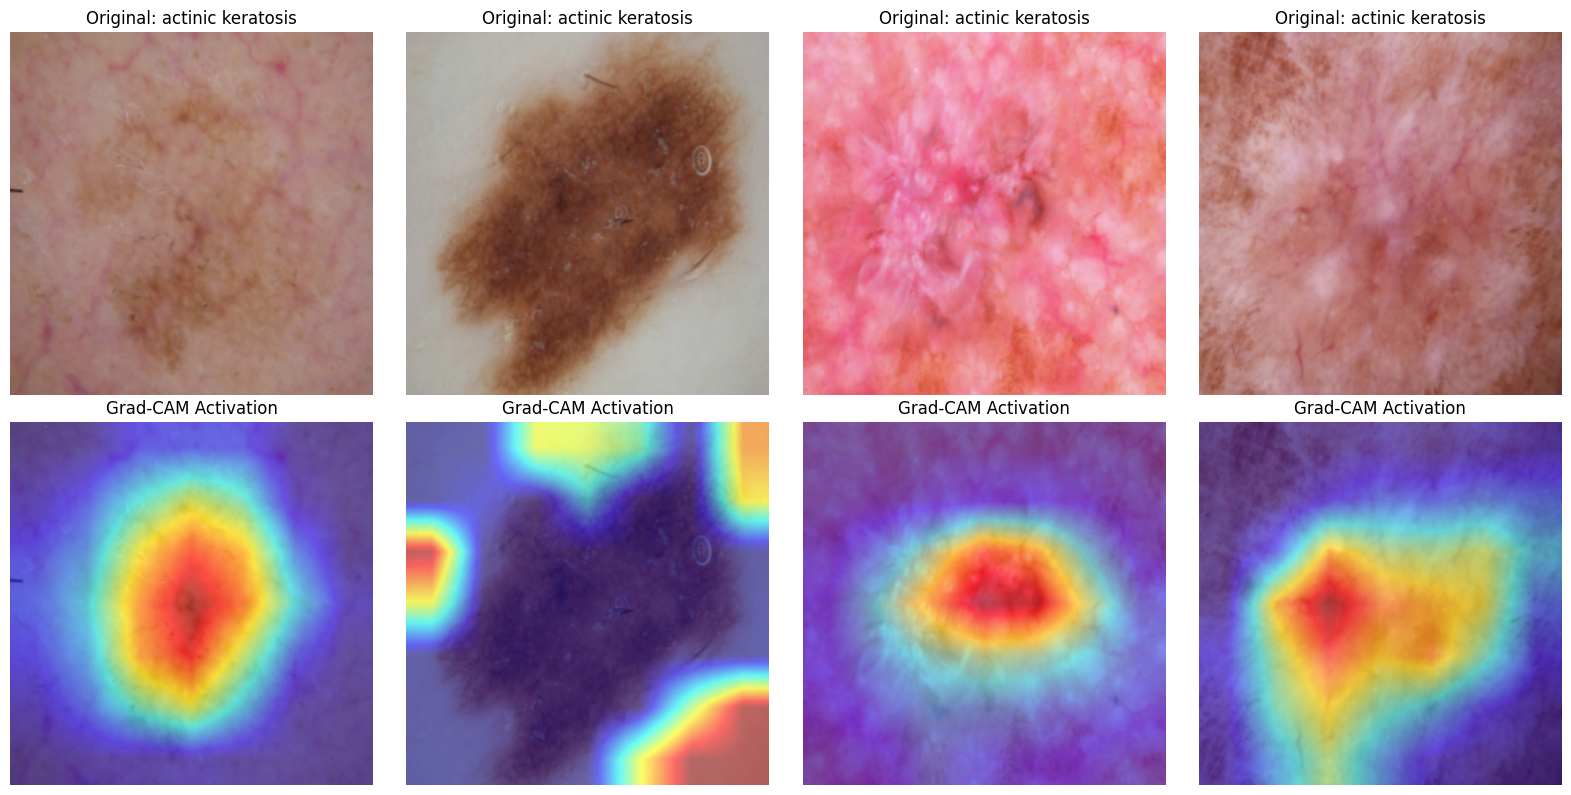

Grad-CAM analysis successfully saved as 'ensemble_gradcam_analysis.png'


In [4]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Load the trained ensemble model (Ensuring we use the best weights)
model = LightweightCNNEnsemble(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load("best_cnn_ensemble_isic.pth"))
model.eval()

# 2. Define the Target Layer
# We target the final convolutional block of the EfficientNet-B0 branch.
# This layer contains the richest spatial and semantic information before pooling.
target_layers = [model.efficientnet.features[-1]]

# 3. Initialize the Grad-CAM object
# We pass the ensemble model, but the gradients will be extracted from the specified layer.
cam = GradCAM(model=model, target_layers=target_layers)

# 4. Fetch a batch of test images for visualization
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

print("Generating Grad-CAM Explanations...")

# Number of images to visualize from the batch
num_images_to_plot = 4
fig, axes = plt.subplots(2, num_images_to_plot, figsize=(16, 8))
class_names = train_dataset.classes

for i in range(num_images_to_plot):
    input_tensor = images[i].unsqueeze(0) # Shape: [1, C, H, W]
    true_label = labels[i].item()
    
    # We want to explain why the model predicted the *actual* ground truth class.
    # Alternatively, you could use `None` to explain the model's highest predicted class.
    targets = [ClassifierOutputTarget(true_label)]
    
    # Generate the raw Grad-CAM mask
    # Output shape is [1, H, W], we select the first batch item
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Reverse ImageNet normalization to display the original RGB image properly
    img_np = images[i].cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_denorm = np.clip((img_np * std) + mean, 0, 1)
    
    # Overlay the heatmap onto the original un-normalized image
    visualization = show_cam_on_image(img_denorm, grayscale_cam, use_rgb=True)
    
    # --- Plotting ---
    # Top Row: Original Image
    axes[0, i].imshow(img_denorm)
    axes[0, i].set_title(f"Original: {class_names[true_label]}", fontsize=12)
    axes[0, i].axis('off')
    
    # Bottom Row: Grad-CAM Overlay
    axes[1, i].imshow(visualization)
    axes[1, i].set_title("Grad-CAM Activation", fontsize=12)
    axes[1, i].axis('off')

# Format and save for publication
plt.tight_layout()
plt.savefig("ensemble_gradcam_analysis.png", bbox_inches='tight', dpi=300)
plt.show()

print("Grad-CAM analysis successfully saved as 'ensemble_gradcam_analysis.png'")